<a href="https://colab.research.google.com/github/JessePMelo/Telco-Customer-Churn/blob/main/data_science/notebooks/02_final_churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction


## Project Overview

This project presents an end-to-end machine learning workflow
to predict customer churn in a telecommunications context.

The objective is not only to build a predictive model, but also
to ensure interpretability, probability calibration, and
business-oriented decision making.


## Business Problem

Customer churn directly impacts revenue and long-term growth.
In competitive markets, retaining existing customers is often
more cost-effective than acquiring new ones.

The business challenge addressed in this project is to identify
customers with a higher risk of churn, enabling proactive actions
such as targeted offers or retention strategies.


## Data Description

The dataset contains customer-level information from a
telecommunications company. It includes demographic data,
service usage details, contract information and billing-related
features.

The target variable indicates whether a customer churned
(binary classification). Both numerical and categorical
features are present, requiring appropriate preprocessing.


## Data Preparation

Data preparation was performed using a structured pipeline
to ensure reproducibility and prevent data leakage.
Numerical and categorical features were handled separately,
and preprocessing steps were applied only after the train-test split.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


In [ ]:
# Load dataset from GitHub repository

url = 'https://raw.githubusercontent.com/JessePMelo/Telco-Customer-Churn/refs/heads/main/data_science/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)


In [ ]:
# Define target variable
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn", "customerID"])


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [ ]:
# Identify feature types
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

# Explicit feature grouping to avoid unintended encoding
categorical_features = [
    'gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

In [ ]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## Modeling Strategy

Logistic Regression was selected as the primary model due to its
interpretability, robustness and suitability for binary
classification problems.

The model was trained using a pipeline to ensure consistent
preprocessing and to avoid data leakage. Class imbalance was
addressed through class weighting, and recall was prioritized
as the main evaluation metric.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [ ]:
# Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)


In [ ]:
# Full modeling pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", log_reg)
    ]
)


In [ ]:
# Train model
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

*Logarithmic and squared transformations were evaluated for selected
numerical features. Although a small performance improvement was
observed, these transformations were not included in the final model
to preserve interpretability and simplicity.*

## Model Evaluation

Model performance was evaluated on a held-out test set.
Recall was prioritized as the main metric, since failing to
identify a churned customer is more costly than a false positive.

Standard classification metrics were reported to provide
a balanced view of model performance.


In [ ]:
from sklearn.metrics import classification_report


In [ ]:
# Predictions on test set
y_pred = model_pipeline.predict(X_test)


*Categorical encoding was configured to safely handle unseen
categories during inference.*

In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)


              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1294
       Churn       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761



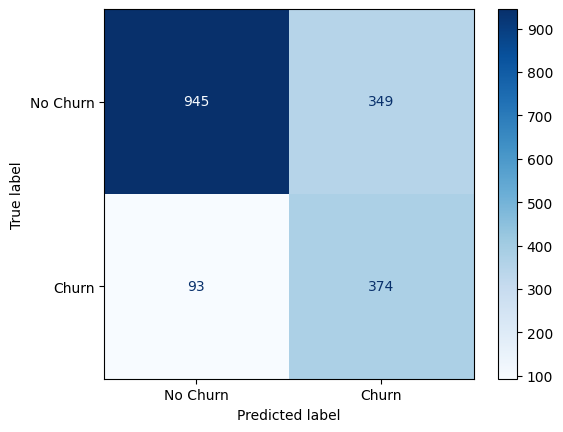

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.show()


## Model Explainability

Model interpretability is essential for trust and decision-making.
To explain predictions, both global and local explanations were
generated, allowing an understanding of overall feature importance
and individual customer-level decisions.


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
# Get feature names after preprocessing
feature_names = model_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()


In [ ]:
# Extract model coefficients
coefficients = model_pipeline.named_steps["model"].coef_[0]


In [ ]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

### Coefficient Analysis

Although Logistic Regression is inherently interpretable, model coefficients were analyzed to quantify the direction and magnitude of each feature’s global impact on the predicted probability of cancellation. Positive coefficients indicate an increased risk, while negative coefficients indicate a protective effect, holding other variables constant.

In [ ]:
coef_df

,feature,coefficient
0,num__SeniorCitizen,0.093627
1,num__tenure,-0.741007
2,num__MonthlyCharges,-0.301650
3,cat__gender_Male,0.013978
4,cat__MultipleLines_No phone service,0.141400
5,cat__MultipleLines_Yes,0.333710
6,cat__InternetService_Fiber optic,1.168939
7,cat__InternetService_No,-0.174634
8,cat__OnlineSecurity_No internet service,-0.174634
9,cat__OnlineSecurity_Yes,-0.383744


### SHAP Validation

Although Logistic Regression is inherently interpretable, SHAP values
were used to validate whether the most influential features identified
by the model coefficients behave consistently across individual
predictions.


In [ ]:
import shap


In [ ]:
# Transform training data using the fitted preprocessing pipeline
X_train_transformed = model_pipeline.named_steps[
    "preprocessing"
].transform(X_train)



In [ ]:
# Initialize SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(
    model_pipeline.named_steps["model"],
    X_train_transformed
)



In [ ]:
# Compute SHAP values
shap_values = explainer.shap_values(X_train_transformed)



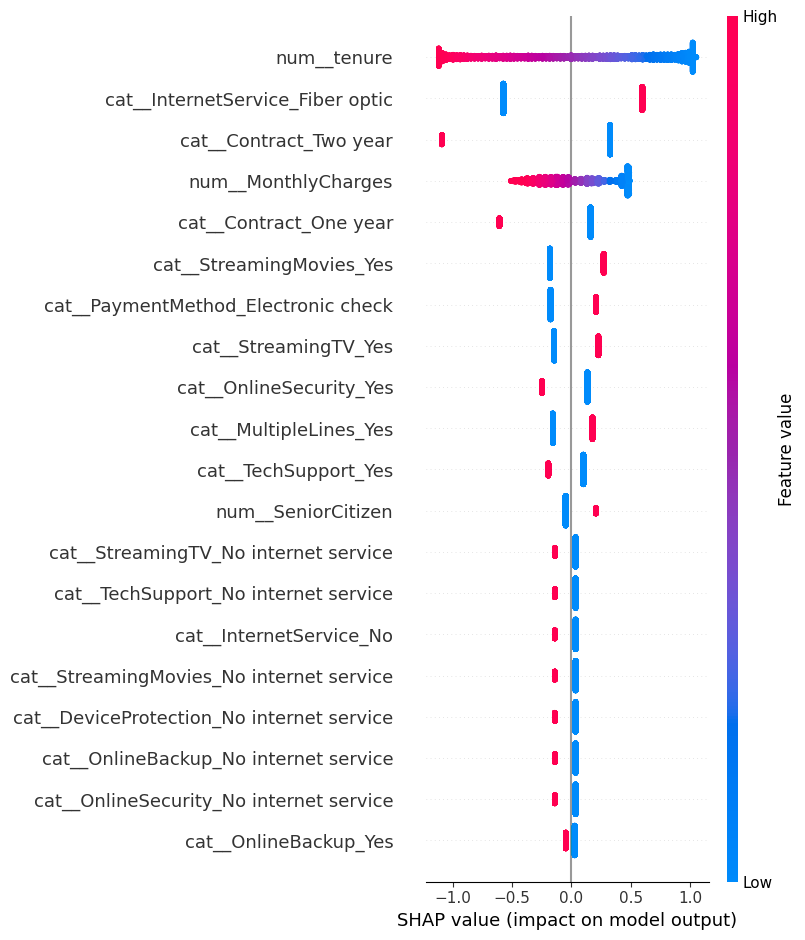

In [ ]:
# Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)


**SHAP Summary Plot Interpretation**

- *Each point represents the impact of a feature value on the churn
prediction for an individual customer.
Red points indicate higher feature values, while blue points represent
lower feature values.
Feature values positioned to the right increase the probability of
customer churn, whereas values positioned to the left contribute to
customer retention.
This analysis confirms that the most influential features identified
by the logistic regression coefficients behave consistently across
individual predictions.*

- *Individual-level SHAP explanations were explored during development but
were omitted from this notebook to maintain a concise, decision-oriented
presentation.*


## Alternative Models

Tree-based models, such as Random Forest, were evaluated to assess
whether non-linear relationships could improve predictive performance.

Although these models achieved competitive results, they were not
selected for the final solution due to reduced interpretability and
less transparent probability estimates when compared to Logistic
Regression.


## Final Model Decision

Although alternative models were evaluated, Logistic Regression was
selected as the final model due to its interpretability, calibrated
probability estimates, and alignment with business decision-making
requirements.

This choice ensures transparent insights, stable predictions, and
actionable outputs suitable for customer retention strategies.


## Conclusion

This project demonstrates an end-to-end churn prediction workflow,
balancing predictive performance and model interpretability.

The final solution delivers reliable churn risk estimates and clear
explanations, enabling data-driven and actionable decisions to support
customer retention strategies.
